# LiH compiled ansatz (FIG. 13)

Six-qubit `CZ` / `H` / `RX` circuit. **FIG. 10** prep is unchanged (includes `X` on `q0` and `q3`. The three `RX` gates on `q[1]` use separate symbols $\theta_1,\theta_2,\theta_3$ (paper-style). With **all three set to 0**, those rotations are identity.

**HF check:** On the **exported active-space Pauli Hamiltonian**, restricted HF is the computational ket **|100100⟩**, i.e. **only** `X` on `LineQubit(0)` and `LineQubit(3)`. The compiled FIG. 13 depth **does not** preserve that ket, so `⟨H⟩` at $\theta_i=0$ on the full circuit will **not** in general equal bare-RHF `⟨H⟩`. The next cell prints both the compiled value and the reference from `X(q0), X(q3)` alone.

**Noise:** Gate-only depolarizing via `GateArityDepolarizingNoise` (density-matrix `Tr[Hρ]`). Later cells add **finite-shot** energy (**OGM**, readout `p_0_success` / `p_1_success`, **REM**) and optional **CDR** calibration on near-Clifford training circuits (needs the same OGM + `SHADOWGROUPING_ROOT`).

0: ───X───Rx(0.5π)───@──────────────────────────────@───────@─────────────────────────────────────────────────────────────────────────@───Rx(-0.5π)───
                     │                              │       │                                                                         │
1: ──────────────────@───────────@───Rx(0.2π)───@───@───H───@───@───@───Rx(0.2π)───@───────────────────────────@───Rx(0.2π)───@───@───@───H───────────
                                 │              │               │   │              │                           │              │   │
2: ───H──────────────────────────┼──────────────┼───────────────@───┼──────────────┼───────────────────────────┼──────────────┼───@───H───────────────
                                 │              │                   │              │                           │              │
3: ───X───H──────────@───────────┼──────────────┼───────────────────┼──────────────┼───────────@───────@───────┼──────────────┼───────@───H───────────


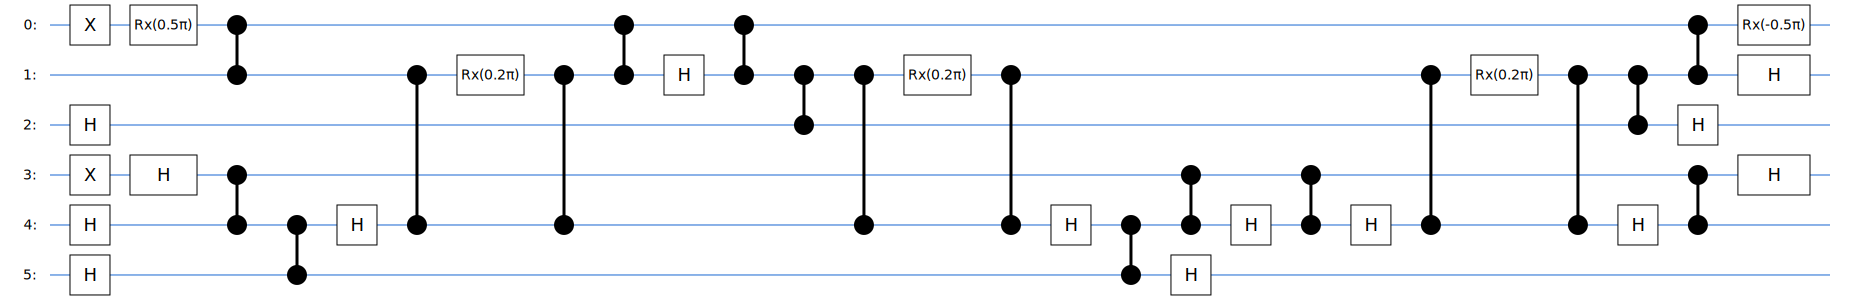

In [13]:
from __future__ import annotations

import cirq
import numpy as np
from cirq.ops import GlobalPhaseGate

# Needed for text/SVG diagrams: top-level ``cirq.GlobalPhaseGate`` can be missing in some kernels.
setattr(cirq, "GlobalPhaseGate", GlobalPhaseGate)

import sympy
from IPython.display import display

from cirq.contrib.svg import SVGCircuit

# Shared sampling/CDR settings used across later notebook cells.
GLOBAL_NUM_SHOTS = 3500
CDR_NUM_TRAINING_CIRCUITS = 3
CDR_T_MAX_GRADIENT = 1
CDR_T_MAX_VQE = 1
CDR_BASE_SEED = 42
GLOBAL_RANDOM_SEED = 1234
GLOBAL_SAMPLING_SEED = 1234
GLOBAL_TWO_QUBIT_GATE_DEPOL_PROB = 0.01
GLOBAL_ONE_QUBIT_GATE_DEPOL_PROB = 0.001
GLOBAL_MEASUREMENT_SCHEME = "ogm"
GLOBAL_APPLY_READOUT_NOISE = True
GLOBAL_READOUT_P0_SUCCESS = np.array([0.9756, 0.9748, 0.9738, 0.9656, 0.9585, 0.9514])
GLOBAL_READOUT_P1_SUCCESS = np.array([0.9756, 0.9748, 0.9738, 0.9656, 0.9585, 0.9514])


def lih_fig13_circuit(
    theta1: sympy.Symbol, theta2: sympy.Symbol, theta3: sympy.Symbol
) -> tuple[cirq.Circuit, list[cirq.LineQubit]]:
    """Compiled LiH ansatz (FIG. 13): three independent ``RX`` angles on ``q[1]``.

    FIG. 10 initial prep (paper): ``R_y(π/5)``, CNOT chain, then ``X`` on ``q0`` and ``q3``.
    """
    q = cirq.LineQubit.range(6)
    q0, q1, q2, q3, q4, q5 = q
    c = cirq.Circuit()
    c.append(cirq.X(q0))
    c.append(cirq.X(q3))

    c.append(cirq.rx(np.pi / 2).on(q0))
    c.append(cirq.H(q2))
    c.append(cirq.H(q3))
    c.append(cirq.H(q4))
    c.append(cirq.H(q5))

    c.append([cirq.CZ(q0, q1), cirq.CZ(q3, q4)])
    c.append([cirq.CZ(q4, q5), cirq.H(q4)])

    c.append(cirq.CZ(q1, q4))
    c.append(cirq.rx(theta1).on(q1))
    c.append(cirq.CZ(q1, q4))

    c.append(cirq.CZ(q0, q1))
    c.append(cirq.H(q1))
    c.append(cirq.CZ(q0, q1))
    c.append(cirq.CZ(q1, q2))

    c.append(cirq.CZ(q1, q4))
    c.append(cirq.rx(theta2).on(q1))
    c.append(cirq.CZ(q1, q4))

    c.append(cirq.H(q4))
    c.append(cirq.CZ(q4, q5))
    c.append(cirq.H(q5))
    c.append(cirq.CZ(q3, q4))
    c.append(cirq.H(q4))
    c.append(cirq.CZ(q3, q4))
    c.append(cirq.H(q4))

    c.append(cirq.CZ(q1, q4))
    c.append(cirq.rx(theta3).on(q1))
    c.append(cirq.CZ(q1, q4))

    c.append(cirq.H(q4))
    c.append(cirq.CZ(q1, q2))
    c.append(cirq.H(q2))
    c.append(cirq.CZ(q0, q1))
    c.append(cirq.CZ(q3, q4))
    c.append(cirq.rx(-np.pi / 2).on(q0))
    c.append([cirq.H(q1), cirq.H(q3)])

    return c, q


theta1 = sympy.Symbol("theta1")
theta2 = sympy.Symbol("theta2")
theta3 = sympy.Symbol("theta3")
circuit, qubits = lih_fig13_circuit(theta1, theta2, theta3)

# Diagram with θ₁ = θ₂ = θ₃ = π/5 (paper-style visualization). HF check uses all zeros in the next cell.
_theta_viz = np.pi / 5
resolver_viz = cirq.ParamResolver({theta1: _theta_viz, theta2: _theta_viz, theta3: _theta_viz})
circuit_draw = cirq.resolve_parameters(circuit, resolver_viz)

print(circuit_draw)
display(SVGCircuit(circuit_draw))

In [14]:
import sys
from pathlib import Path

# Repo root resolution for local file loading.
_repo = Path.cwd().resolve()
if not (_repo / "main_cursor_lib.py").is_file():
    _repo = _repo.parent
sys.path.insert(0, str(_repo))


# Read numbered-Pauli Hamiltonian from Pauli_Ham/LiH_bond_<bond>.txt.
def load_pauli_sum_from_numbered_file(path: Path, qubits: list[cirq.Qid]) -> cirq.PauliSum:
    idx_to_pauli = {1: cirq.X, 2: cirq.Y, 3: cirq.Z}
    out = cirq.PauliSum()

    with path.open("r", encoding="utf-8") as f:
        for lineno, raw in enumerate(f, start=1):
            line = raw.strip()
            if not line:
                continue

            parts = line.split()
            coeff = float(parts[0])
            pauli_codes = [int(x) for x in parts[1:]]

            if len(pauli_codes) != len(qubits):
                raise ValueError(
                    f"{path}:{lineno} has {len(pauli_codes)} Pauli indices, expected {len(qubits)}."
                )

            pauli_string = cirq.PauliString()
            for q, code in zip(qubits, pauli_codes):
                if code == 0:
                    continue
                if code not in idx_to_pauli:
                    raise ValueError(f"{path}:{lineno} has invalid Pauli code {code}; expected 0/1/2/3.")
                pauli_string *= idx_to_pauli[code](q)

            out += coeff * pauli_string

    return out


bond_length = 2.2
ham_path = _repo / "Pauli_Ham" / f"LiH_bond_{bond_length:.1f}.txt"

# θ₁ = θ₂ = θ₃ = 0 → the three ``RX`` gates on ``q1`` are identity; FIG. 10 + FIG. 13 still apply other gates.
resolver = cirq.ParamResolver({theta1: 0.0, theta2: 0.0, theta3: 0.0})
resolved = cirq.resolve_parameters(circuit, resolver)

sim = cirq.Simulator()
result = sim.simulate(resolved, qubit_order=qubits)
psi = np.asarray(result.final_state_vector, dtype=np.complex128)

print(f"qubits: {len(qubits)}  state_dim: {len(psi)}")
assert len(psi) == 2 ** len(qubits)

pauli_sum = load_pauli_sum_from_numbered_file(ham_path, list(qubits))
qubit_map = {q: i for i, q in enumerate(qubits)}
e_compiled = float(np.real(pauli_sum.expectation_from_state_vector(psi, qubit_map=qubit_map)))

# Reference: active-space ⟨H⟩ on spin-block RHF ket |100100⟩ = X on q0 and q3 only (no FIG. 10 / FIG. 13).
psi_hf = cirq.Simulator().simulate(
    cirq.Circuit(cirq.X(qubits[0]), cirq.X(qubits[3])),
    qubit_order=qubits,
).final_state_vector
e_hf_ref = float(
    np.real(pauli_sum.expectation_from_state_vector(np.asarray(psi_hf, dtype=np.complex128), qubit_map=qubit_map))
)

print(f"\nLiH bond {bond_length} Å")
print(f"Hamiltonian source: {ham_path}")
print(f"⟨H⟩ compiled FIG. 10 + FIG. 13 with θ₁=θ₂=θ₃=0: {e_compiled:.10f} Eh")
print(f"⟨H⟩ reference |100100⟩ (X on LineQubit(0) and LineQubit(3) only): {e_hf_ref:.10f} Eh")

qubits: 6  state_dim: 64

LiH bond 2.2 Å
Hamiltonian source: /Users/zacharyhe/cross_chips_sim/Pauli_Ham/LiH_bond_2.2.txt
⟨H⟩ compiled FIG. 10 + FIG. 13 with θ₁=θ₂=θ₃=0: -7.8079943693 Eh
⟨H⟩ reference |100100⟩ (X on LineQubit(0) and LineQubit(3) only): -7.8079943693 Eh


In [15]:
# Evaluate FIG. 13 compiled ansatz energy at params = [0.0, 0.07, 0.0].
params = np.array([-0.444980732142,0.476365247616, 0.142686033100], dtype=float)
resolver_test = cirq.ParamResolver({theta1: params[0], theta2: params[1], theta3: params[2]})

resolved_test = cirq.resolve_parameters(circuit, resolver_test)
psi_test = np.asarray(
    cirq.Simulator().simulate(resolved_test, qubit_order=qubits).final_state_vector,
    dtype=np.complex128,
)
e_test = float(np.real(pauli_sum.expectation_from_state_vector(psi_test, qubit_map=qubit_map)))

print(f"params = {params.tolist()}")
print(f"E(params) = {e_test:.10f} Eh")

params = [-0.444980732142, 0.476365247616, 0.1426860331]
E(params) = -7.8290523999 Eh


In [16]:
# Noisy energy: ``GateArityDepolarizingNoise`` adds single-qubit depolarizing channels after
# each gate — 2Q gates → ``two_qubit_depol_prob`` on both lines; 1Q gates → ``one_qubit_depol_prob``.
# No measurement noise here (density matrix + Tr[H ρ]).
import sys
from pathlib import Path

_repo = Path.cwd().resolve()
if not (_repo / "main_cursor_lib.py").is_file():
    _repo = _repo.parent
for _p in (str(_repo), str(_repo / "test_LiH_case")):
    if _p not in sys.path:
        sys.path.insert(0, _p)

from main_cursor_lib_test_LiH import (
    GateArityDepolarizingNoise,
    ONE_QUBIT_GATE_DEPOL_PROB,
    TWO_QUBIT_GATE_DEPOL_PROB,
    trace_energy,
)

random_seed = int(globals()["GLOBAL_RANDOM_SEED"])

gate_noise = GateArityDepolarizingNoise(
    two_qubit_depol_prob=TWO_QUBIT_GATE_DEPOL_PROB,
    one_qubit_depol_prob=ONE_QUBIT_GATE_DEPOL_PROB,
)
noisy_ansatz = circuit.with_noise(gate_noise)
resolver_noisy = cirq.ParamResolver(
    {theta1: float(params[0]), theta2: float(params[1]), theta3: float(params[2])}
)
resolved_noisy = cirq.resolve_parameters(noisy_ansatz, resolver_noisy)

rho_noisy = np.asarray(
    cirq.DensityMatrixSimulator(seed=random_seed)
    .simulate(resolved_noisy, qubit_order=qubits)
    .final_density_matrix,
    dtype=np.complex128,
)

hamiltonian_matrix = pauli_sum.matrix(qubits=qubits)
trace_noisy_energy = trace_energy(hamiltonian_matrix, rho_noisy)

print(
    f"noise: two_qubit_depol={gate_noise.two_qubit_depol_prob} "
    f"one_qubit_depol={gate_noise.one_qubit_depol_prob}"
)
print(f"params = {params.tolist()}")
print(f"Tr[H ρ_noisy] (gate noise only): {trace_noisy_energy:.10f} Eh")

noise: two_qubit_depol=0.018 one_qubit_depol=0.0018
params = [-0.444980732142, 0.476365247616, 0.1426860331]
Tr[H ρ_noisy] (gate noise only): -7.6692318758 Eh


In [17]:
# Finite-shot energy from the same ``rho_noisy`` as above: OGM measurement layout + asymmetric
# readout (``p_0_success`` / ``p_1_success`` on LineQubit 0…5) and optional REM in post-processing.
# This cell is kept compatible with the current gate-arity depolarizing workflow
# (no legacy DEFAULT_AMP_DAMP_GAMMA / LocationAware noise constants in main_cursor_lib_test_LiH).
import json
import sys
from pathlib import Path

_repo = Path.cwd().resolve()
if not (_repo / "main_cursor_lib.py").is_file():
    _repo = _repo.parent
for _p in (str(_repo), str(_repo / "test_LiH_case")):
    if _p not in sys.path:
        sys.path.insert(0, _p)

_DEBUG_LOG_PATH = Path("/Users/zacharyhe/cross_chips_sim/.cursor/debug-f457d0.log")
_DEBUG_RUN_ID = "pre-fix-cell5"


def _agent_log(hypothesis_id: str, location: str, message: str, data: dict) -> None:
    payload = {
        "sessionId": "f457d0",
        "runId": _DEBUG_RUN_ID,
        "hypothesisId": hypothesis_id,
        "location": location,
        "message": message,
        "data": data,
        "timestamp": int(__import__("time").time() * 1000),
    }
    with _DEBUG_LOG_PATH.open("a", encoding="utf-8") as _f:
        _f.write(json.dumps(payload, ensure_ascii=True) + "\n")


# Prefer the test helper, but fall back to the shared helper if the test helper still
# references removed legacy noise constants.
_import_source = "unknown"
try:
    from shot_measurement_test_LiH import estimate_energy_from_noisy_rho_shots

    _import_source = "shot_measurement_test_LiH"
except ImportError as _imp_err:
    from shot_measurement import estimate_energy_from_noisy_rho_shots

    _import_source = "shot_measurement"
    # region agent log
    _agent_log(
        "H1",
        "lih_fig13_compiled_ansatz.ipynb:cell5",
        "fallback import used",
        {"error": str(_imp_err)},
    )
    # endregion

# region agent log
_agent_log(
    "H1",
    "lih_fig13_compiled_ansatz.ipynb:cell5",
    "import source selected",
    {"import_source": _import_source},
)
# endregion

num_shots = int(globals()["GLOBAL_NUM_SHOTS"])
measurement_scheme = str(globals()["GLOBAL_MEASUREMENT_SCHEME"])
sampling_seed = int(globals()["GLOBAL_SAMPLING_SEED"])
epsilon = 0.1

p_0_success = np.array(globals()["GLOBAL_READOUT_P0_SUCCESS"], dtype=float)
p_1_success = np.array(globals()["GLOBAL_READOUT_P1_SUCCESS"], dtype=float)

apply_readout_noise = bool(globals()["GLOBAL_APPLY_READOUT_NOISE"])
apply_rem = True

SHADOWGROUPING_ROOT = globals().get("SHADOWGROUPING_ROOT", "/Users/zacharyhe/shadowgrouping")
ogm_file = globals().get(
    "ogm_file",
    Path(f"{SHADOWGROUPING_ROOT}/haozhaowu/LiH/hamil_class/ogm_outputs/OGM_ogm_LiH_{bond_length:.1f}.txt"),
)

# region agent log
_agent_log(
    "H2",
    "lih_fig13_compiled_ansatz.ipynb:cell5",
    "path checks",
    {
        "ogm_exists": bool(ogm_file.is_file()),
        "shadow_root_exists": bool(Path(SHADOWGROUPING_ROOT).is_dir()),
        "measurement_scheme": measurement_scheme,
        "num_shots": int(num_shots),
    },
)
# endregion

print(f"OGM file: {ogm_file}  exists={ogm_file.is_file()}")

if not ogm_file.is_file():
    # region agent log
    _agent_log(
        "H2",
        "lih_fig13_compiled_ansatz.ipynb:cell5",
        "skipped due to missing ogm file",
        {"ogm_file": str(ogm_file)},
    )
    # endregion
    print(
        "Skip OGM shot estimate: OGM file missing. Generate LiH OGM at this bond or set SHADOWGROUPING_ROOT."
    )
elif not Path(SHADOWGROUPING_ROOT).is_dir():
    # region agent log
    _agent_log(
        "H2",
        "lih_fig13_compiled_ansatz.ipynb:cell5",
        "skipped due to missing shadow root",
        {"shadow_root": SHADOWGROUPING_ROOT},
    )
    # endregion
    print("Skip OGM shot estimate: SHADOWGROUPING_ROOT does not exist.")
else:
    try:
        shot_est = estimate_energy_from_noisy_rho_shots(
            rho_noisy,
            pauli_sum,
            qubits,
            num_shots=num_shots,
            measurement_scheme=measurement_scheme,
            p_0_success=p_0_success,
            p_1_success=p_1_success,
            apply_rem=apply_rem,
            apply_readout_noise=apply_readout_noise,
            sampling_seed=sampling_seed,
            epsilon=epsilon,
            ogm_file=ogm_file,
            shadowgrouping_root=SHADOWGROUPING_ROOT,
        )
        eu = float(shot_est["energy_unmitigated"])
        er = float(shot_est["energy_rem"])

        # region agent log
        _agent_log(
            "H3",
            "lih_fig13_compiled_ansatz.ipynb:cell5",
            "shot estimate success",
            {"energy_unmitigated": eu, "energy_rem": er},
        )
        # endregion

        print(f"Finite-shot energy (readout noise, no REM correction): {eu:.12f} Eh")
        print(f"Finite-shot energy (REM readout mitigation):          {er:.12f} Eh")
        print(f"REM delta (REM - raw shots):                            {er - eu:.12f} Eh")
        print(
            f"\nReference Tr[H ρ] (same ρ, exact Pauli from DM; no shot noise): {trace_noisy_energy:.12f} Eh"
        )
    except Exception as _run_err:
        # region agent log
        _agent_log(
            "H3",
            "lih_fig13_compiled_ansatz.ipynb:cell5",
            "shot estimate failed",
            {
                "error_type": type(_run_err).__name__,
                "error": str(_run_err),
            },
        )
        # endregion
        raise

OGM file: /Users/zacharyhe/shadowgrouping/haozhaowu/LiH/hamil_class/ogm_outputs/OGM_ogm_LiH_2.2.txt  exists=True
Finite-shot energy (readout noise, no REM correction): -7.640049281956 Eh
Finite-shot energy (REM readout mitigation):          -7.696684934028 Eh
REM delta (REM - raw shots):                            -0.056635652072 Eh

Reference Tr[H ρ] (same ρ, exact Pauli from DM; no shot noise): -7.669231875768 Eh


In [18]:
# Head-to-head: default per-Pauli CDR vs legacy total-energy CDR (same config, mode='cdr').
import sys
from pathlib import Path

import cirq
import numpy as np

_repo = Path.cwd().resolve()
if not (_repo / "main_cursor_lib.py").is_file():
    _repo = _repo.parent
for _p in (str(_repo), str(_repo / "test_LiH_case")):
    if _p not in sys.path:
        sys.path.insert(0, _p)

from main_cursor_lib_test_LiH import ONE_QUBIT_GATE_DEPOL_PROB, TWO_QUBIT_GATE_DEPOL_PROB
from shot_measurement_test_LiH import run_mitigation

symbols_li_h = [theta1, theta2, theta3]
target_resolver = {theta1: float(params[0]), theta2: float(params[1]), theta3: float(params[2])}

base_noise_cfg = {
    "two_qubit_depol_prob": TWO_QUBIT_GATE_DEPOL_PROB,
    "one_qubit_depol_prob": ONE_QUBIT_GATE_DEPOL_PROB,
}

shot_cfg = {
    "num_shots": int(globals().get("num_shots", globals()["GLOBAL_NUM_SHOTS"])),
    "measurement_scheme": str(globals().get("measurement_scheme", globals()["GLOBAL_MEASUREMENT_SCHEME"])),
    "apply_readout_noise": bool(globals().get("apply_readout_noise", globals()["GLOBAL_APPLY_READOUT_NOISE"])),
    "sampling_seed": int(globals().get("sampling_seed", globals()["GLOBAL_SAMPLING_SEED"])),
    "ogm_file": globals().get(
        "ogm_file",
        Path(
            f"{globals().get('SHADOWGROUPING_ROOT', '/Users/zacharyhe/shadowgrouping')}/haozhaowu/LiH/hamil_class/ogm_outputs/OGM_ogm_LiH_{bond_length:.1f}.txt"
        ),
    ),
    "shadowgrouping_root": globals().get("SHADOWGROUPING_ROOT", "/Users/zacharyhe/shadowgrouping"),
}
readout_cal = {
    "p_0_success": np.array(globals().get("p_0_success", globals()["GLOBAL_READOUT_P0_SUCCESS"]), dtype=float),
    "p_1_success": np.array(globals().get("p_1_success", globals()["GLOBAL_READOUT_P1_SUCCESS"]), dtype=float),
}

cdr_cfg_base = dict(
    num_circuits=int(globals().get("CDR_NUM_TRAINING_CIRCUITS", globals()["CDR_NUM_TRAINING_CIRCUITS"])),
    t_max=int(globals().get("CDR_T_MAX_VQE", globals()["CDR_T_MAX_VQE"])),
    seed=int(globals().get("CDR_BASE_SEED", globals()["CDR_BASE_SEED"])),
)

if not Path(shot_cfg["shadowgrouping_root"]).is_dir() or not Path(shot_cfg["ogm_file"]).is_file():
    print("Skip CDR: need valid ogm_file and SHADOWGROUPING_ROOT (same as OGM shot cell).")
else:
    mit_pp = run_mitigation(
        "cdr",
        ansatz_circuit=circuit,
        observable_h=pauli_sum,
        qubits=qubits,
        target_resolver=target_resolver,
        target_params=target_resolver,
        symbols=symbols_li_h,
        base_noise_cfg=base_noise_cfg,
        shot_cfg=shot_cfg,
        readout_cal=readout_cal,
        cdr_cfg={**cdr_cfg_base},
        simulator_seed=int(globals().get("random_seed", globals()["GLOBAL_RANDOM_SEED"])),
    )
    if "e_test" in globals():
        eref = float(e_test)
    else:
        resolved_target = cirq.resolve_parameters(circuit, cirq.ParamResolver(target_resolver))
        psi_target = cirq.Simulator(
            seed=int(globals().get("random_seed", globals()["GLOBAL_RANDOM_SEED"]))
        ).simulate(resolved_target, qubit_order=qubits).final_state_vector
        h_mat = pauli_sum.matrix(qubits=qubits)
        eref = float(np.vdot(psi_target, h_mat @ psi_target).real)

    print("CDR (per-pauli)")
    print(
        f"raw finite-shot (unmit / REM): {float(mit_pp['unmit_target']):.12f} / {float(mit_pp['rem_target']):.12f} Eh"
    )
    print(
        "cdr corrected (unmit / REM): "
        f"{float(mit_pp['cdr_unmit_corrected']):.12f} / {float(mit_pp['cdr_rem_corrected']):.12f} Eh"
    )
    print(f"reference exact noiseless: {eref:.12f} Eh")
    print(f"Energy error: {eref - float(mit_pp['cdr_rem_corrected']):.12f} Eh")

CDR (per-pauli)
raw finite-shot (unmit / REM): -7.624765351069 / -7.671120103335 Eh
cdr corrected (unmit / REM): -7.799417796856 / -7.799417796856 Eh
reference exact noiseless: -7.829052399882 Eh
Energy error: -0.029634603026 Eh


## Parameter-shift gradients with CDR objective

For a pure expectation objective with `RX(θ) = exp(-i θ X / 2)`, the [parameter-shift rule](https://pennylane.ai/qml/glossary/parameter_shift)

$$\frac{\partial}{\partial \theta}\langle H \rangle = \frac{1}{2}\Big[\langle H \rangle(\theta + \pi/2) - \langle H \rangle(\theta - \pi/2)\Big]$$

is exact gate-by-gate.

In this section, `energy_from_params` defaults to the **CDR-corrected REM energy** objective (`cdr_rem_corrected`) so gradients are taken for the mitigated pipeline. Because this objective includes noisy-shot estimation + learned CDR correction, parameter-shift here is used as a **numerical gradient estimator** (not an exact identity). We therefore cross-check against central finite differences with a practical tolerance.


In [19]:
# Gradients for the mitigated objective: CDR-corrected REM energy by default.
import numpy as np
import cirq

_grad_sim = cirq.Simulator(seed=int(globals().get("random_seed", globals()["GLOBAL_RANDOM_SEED"])))
_PARAM_SHIFT = np.pi / 2.0
_DEFAULT_ENERGY_MODE = "cdr_rem_corrected"


def _resolver_from_params(params_vec: np.ndarray) -> dict:
    p = np.asarray(params_vec, dtype=float).reshape(3)
    return {theta1: float(p[0]), theta2: float(p[1]), theta3: float(p[2])}


def _noiseless_energy(params_vec: np.ndarray) -> float:
    """Exact noiseless statevector expectation ⟨H⟩."""
    resolver = cirq.ParamResolver(_resolver_from_params(params_vec))
    resolved = cirq.resolve_parameters(circuit, resolver)
    psi = np.asarray(
        _grad_sim.simulate(resolved, qubit_order=qubits).final_state_vector,
        dtype=np.complex128,
    )
    return float(np.real(pauli_sum.expectation_from_state_vector(psi, qubit_map=qubit_map)))


def _cdr_rem_corrected_energy(params_vec: np.ndarray) -> float:
    """CDR-corrected REM target energy from ``run_mitigation(mode='cdr')``."""
    if "run_mitigation" not in globals():
        raise RuntimeError("run_mitigation not found. Run the CDR setup cell first.")

    resolver = _resolver_from_params(params_vec)
    symbols = globals().get("symbols_li_h", [theta1, theta2, theta3])

    base_noise = dict(
        globals().get(
            "base_noise_cfg",
            {
                "two_qubit_depol_prob": float(
                    globals().get("TWO_QUBIT_GATE_DEPOL_PROB", globals()["GLOBAL_TWO_QUBIT_GATE_DEPOL_PROB"])
                ),
                "one_qubit_depol_prob": float(
                    globals().get("ONE_QUBIT_GATE_DEPOL_PROB", globals()["GLOBAL_ONE_QUBIT_GATE_DEPOL_PROB"])
                ),
            },
        )
    )
    shot_cfg_local = dict(globals().get("shot_cfg", {}))
    shot_cfg_local.setdefault("num_shots", int(globals().get("num_shots", globals()["GLOBAL_NUM_SHOTS"])))
    shot_cfg_local.setdefault("measurement_scheme", str(globals()["GLOBAL_MEASUREMENT_SCHEME"]))
    shot_cfg_local.setdefault("apply_readout_noise", bool(globals()["GLOBAL_APPLY_READOUT_NOISE"]))
    shot_cfg_local.setdefault("sampling_seed", int(globals().get("sampling_seed", globals()["GLOBAL_SAMPLING_SEED"])))

    readout_cal_local = dict(globals().get("readout_cal", {}))
    readout_cal_local.setdefault("p_0_success", np.array(globals()["GLOBAL_READOUT_P0_SUCCESS"], dtype=float))
    readout_cal_local.setdefault("p_1_success", np.array(globals()["GLOBAL_READOUT_P1_SUCCESS"], dtype=float))

    cdr_cfg_local = dict(
        globals().get(
            "cdr_cfg_base",
            {
                "num_circuits": int(globals()["CDR_NUM_TRAINING_CIRCUITS"]),
                "t_max": int(globals()["CDR_T_MAX_GRADIENT"]),
                "seed": int(globals()["CDR_BASE_SEED"]),
            },
        )
    )

    mit = run_mitigation(
        "cdr",
        ansatz_circuit=circuit,
        observable_h=pauli_sum,
        qubits=qubits,
        target_resolver=resolver,
        target_params=resolver,
        symbols=symbols,
        base_noise_cfg=base_noise,
        shot_cfg=shot_cfg_local,
        readout_cal=readout_cal_local,
        cdr_cfg=cdr_cfg_local,
        simulator_seed=int(globals().get("random_seed", globals()["GLOBAL_RANDOM_SEED"])),
    )
    return float(mit["cdr_rem_corrected"])


def energy_from_params(params_vec: np.ndarray, energy_mode: str = _DEFAULT_ENERGY_MODE) -> float:
    """Objective energy at params.

    Supported modes:
      - ``cdr_rem_corrected`` (default): mitigated target from CDR + REM
      - ``noiseless``: exact statevector expectation
    """
    mode = str(energy_mode).strip().lower()
    if mode in {"cdr", "cdr_rem", "cdr_rem_corrected"}:
        return _cdr_rem_corrected_energy(params_vec)
    if mode in {"noiseless", "exact", "statevector"}:
        return _noiseless_energy(params_vec)
    raise ValueError(f"Unsupported energy_mode={energy_mode!r}.")


def parameter_shift_gradient(params_vec: np.ndarray, energy_mode: str = _DEFAULT_ENERGY_MODE) -> np.ndarray:
    """Gradient estimator via ±π/2 shifts (exact only for pure expectation objectives)."""
    g = np.zeros(3, dtype=float)
    p = np.asarray(params_vec, dtype=float).reshape(3)
    for i in range(3):
        plus = p.copy()
        minus = p.copy()
        plus[i] += _PARAM_SHIFT
        minus[i] -= _PARAM_SHIFT
        g[i] = 0.5 * (
            energy_from_params(plus, energy_mode=energy_mode)
            - energy_from_params(minus, energy_mode=energy_mode)
        )
    return g


def finite_difference_gradient(
    params_vec: np.ndarray,
    eps: float = 2e-2,
    energy_mode: str = _DEFAULT_ENERGY_MODE,
) -> np.ndarray:
    """Central finite-difference gradient for the selected objective."""
    g = np.zeros(3, dtype=float)
    p = np.asarray(params_vec, dtype=float).reshape(3)
    for i in range(3):
        plus = p.copy()
        minus = p.copy()
        plus[i] += eps
        minus[i] -= eps
        g[i] = (
            energy_from_params(plus, energy_mode=energy_mode)
            - energy_from_params(minus, energy_mode=energy_mode)
        ) / (2.0 * eps)
    return g


In [20]:
# # Gradient checks:
# # 1) CDR-corrected REM objective (informational: estimator-vs-estimator)
# # 2) Noiseless objective (strict assertion)

# _ps_params = np.asarray(
#     globals().get(
#         "params",
#         np.array([-0.444980732142, 0.476365247616, 0.142686033100], dtype=float),
#     ),
#     dtype=float,
# ).reshape(3)

# _energy_mode = "cdr_rem_corrected"
# if _energy_mode.startswith("cdr"):
#     _required = ["run_mitigation", "base_noise_cfg", "shot_cfg", "readout_cal", "symbols_li_h"]
#     _missing = [name for name in _required if name not in globals()]
#     if _missing:
#         raise RuntimeError(
#             "CDR objective needs the CDR setup cell first. Missing globals: " + ", ".join(_missing)
#         )

# cdr_energy = energy_from_params(_ps_params, energy_mode=_energy_mode)
# cdr_ps_grad = parameter_shift_gradient(_ps_params, energy_mode=_energy_mode)
# _cdr_fd_eps = 2e-2
# cdr_fd_grad = finite_difference_gradient(_ps_params, eps=_cdr_fd_eps, energy_mode=_energy_mode)

# print("[CDR objective]")
# print("energy_mode:", _energy_mode)
# print("objective energy:", cdr_energy)
# print("params:", _ps_params)
# print("parameter_shift grad:", cdr_ps_grad)
# print(f"finite_difference grad (eps={_cdr_fd_eps}):", cdr_fd_grad)
# print("abs diff |ps - fd|:", np.abs(cdr_ps_grad - cdr_fd_grad))
# print("max abs diff:", float(np.max(np.abs(cdr_ps_grad - cdr_fd_grad))))

# # Strict numerical check on pure noiseless objective where PS is exact for RX gates.
# _ref_mode = "noiseless"
# _ref_fd_eps = 5e-3
# ref_ps_grad = parameter_shift_gradient(_ps_params, energy_mode=_ref_mode)
# ref_fd_grad = finite_difference_gradient(_ps_params, eps=_ref_fd_eps, energy_mode=_ref_mode)

# print("\n[Noiseless reference check]")
# print("parameter_shift grad:", ref_ps_grad)
# print(f"finite_difference grad (eps={_ref_fd_eps}):", ref_fd_grad)
# print("abs diff |ps - fd|:", np.abs(ref_ps_grad - ref_fd_grad))

# _ref_atol = 5e-4
# np.testing.assert_allclose(ref_ps_grad, ref_fd_grad, rtol=0.0, atol=_ref_atol)
# print("OK: noiseless parameter-shift matches finite differences within atol =", _ref_atol)


## VQE with CDR+REM + parameter-shift (Adam)

This section implements the workflow from the paper figure:

1. **Gradient**: estimate $\partial E/\partial \theta_i$ with the **parameter-shift** recipe using the **CDR-corrected REM** objective $E(\theta)=\texttt{cdr\_rem\_corrected}$ from `run_mitigation("cdr", ...)`.
2. **Full update**: each iteration, evaluate gradients for **all 3 trainable RX angles** and apply an **Adam** parameter update on all coordinates.
3. **Energy record**: after the update, evaluate $E(\theta)$ again and append to the optimisation trace.
4. **Stop**: run exactly `15` iterations.

**Step size (learning rate)**: `VQE_LR` is chosen by a short **warmup scan** over `VQE_LR_GRID` (unless `VQE_LR_WARMUP` is False), running `VQE_WARMUP_ITERS` mini-iterations per candidate. Each mini-iteration uses a full parameter-shift gradient ($2N$ objective evaluations) plus one post-update energy ($+1$). The candidate with the **lowest final** mitigated energy wins. If warmup is disabled, `VQE_LR = VQE_LR_FALLBACK` (default `0.03`).

**Energy evaluation counting**: every call to `energy_from_params(..., "cdr_rem_corrected")` counts as **one outer objective evaluation** (each runs a full CDR pipeline including inner shot sampling). With $N=3$, each warmup/main iteration therefore uses $2N+1=7$ outer objective evaluations. The printed total is the sum of all such calls in init / warmup / main / final.


In [21]:
# --- VQE configuration (CDR+REM + parameter-shift + Adam) ---

# Optimisation (fixed length)
VQE_ITERS = 15
VQE_ADAM_BETA1 = 0.9
VQE_ADAM_BETA2 = 0.999
VQE_ADAM_EPS = 1e-8

# Learning-rate policy (see markdown above)
VQE_LR_WARMUP = True
VQE_LR_GRID = (0.01, 0.03, 0.05)
VQE_WARMUP_ITERS = 1  # K mini-iters per candidate in grid
VQE_LR_FALLBACK = 0.01

# Reproducible random seed for VQE parameter initialisation
VQE_SEED = 12

# Require upstream CDR globals (run the CDR setup cell first)
_req = ["run_mitigation", "base_noise_cfg", "shot_cfg", "readout_cal", "symbols_li_h", "circuit", "pauli_sum", "qubits", "theta1", "theta2", "theta3"]
_miss = [n for n in _req if n not in globals()]
if _miss:
    raise RuntimeError("Missing notebook globals: " + ", ".join(_miss))


In [22]:
# --- VQE loop: Adam + full 3-parameter updates ---
import numpy as np

_ENERGY_MODE = "cdr_rem_corrected"
_rng_vqe = np.random.default_rng(int(VQE_SEED))

# Count every outer ``cdr_rem_corrected`` objective evaluation (``energy_from_params`` / ``run_mitigation``).
_n_energy_total = 0
_n_init = 0
_n_warmup = 0
_n_main_grad = 0
_n_main_post = 0
_n_final = 0
_n_noiseless_track = 0


def _vqe_energy(p, bucket: str) -> float:
    global _n_energy_total
    _n_energy_total += 1
    if bucket == "init":
        global _n_init
        _n_init += 1
    elif bucket == "warmup":
        global _n_warmup
        _n_warmup += 1
    elif bucket == "main_grad":
        global _n_main_grad
        _n_main_grad += 1
    elif bucket == "main_post":
        global _n_main_post
        _n_main_post += 1
    elif bucket == "final":
        global _n_final
        _n_final += 1
    else:
        raise ValueError(bucket)
    return float(energy_from_params(np.asarray(p, dtype=float).reshape(3), energy_mode=_ENERGY_MODE))


def _vqe_run_mitigation_triple(p, bucket: str) -> tuple[float, float, float]:
    """One ``run_mitigation("cdr", ...)`` call -> (raw finite-shot, REM, REM+CF)."""
    global _n_energy_total
    _n_energy_total += 1
    if bucket == "init":
        global _n_init
        _n_init += 1
    elif bucket == "warmup":
        global _n_warmup
        _n_warmup += 1
    elif bucket == "main_post":
        global _n_main_post
        _n_main_post += 1
    elif bucket == "final":
        global _n_final
        _n_final += 1
    else:
        raise ValueError(bucket)

    pv = np.asarray(p, dtype=float).reshape(3)
    resolver = {theta1: float(pv[0]), theta2: float(pv[1]), theta3: float(pv[2])}
    symbols = globals().get("symbols_li_h", [theta1, theta2, theta3])
    base_noise = dict(
        globals().get(
            "base_noise_cfg",
            {
                "two_qubit_depol_prob": float(
                    globals().get("TWO_QUBIT_GATE_DEPOL_PROB", globals()["GLOBAL_TWO_QUBIT_GATE_DEPOL_PROB"])
                ),
                "one_qubit_depol_prob": float(
                    globals().get("ONE_QUBIT_GATE_DEPOL_PROB", globals()["GLOBAL_ONE_QUBIT_GATE_DEPOL_PROB"])
                ),
            },
        )
    )
    shot_cfg_local = dict(globals().get("shot_cfg", {}))
    shot_cfg_local.setdefault("num_shots", int(globals().get("num_shots", globals()["GLOBAL_NUM_SHOTS"])))
    shot_cfg_local.setdefault("measurement_scheme", str(globals()["GLOBAL_MEASUREMENT_SCHEME"]))
    shot_cfg_local.setdefault("apply_readout_noise", bool(globals()["GLOBAL_APPLY_READOUT_NOISE"]))
    shot_cfg_local.setdefault("sampling_seed", int(globals().get("sampling_seed", globals()["GLOBAL_SAMPLING_SEED"])))
    readout_cal_local = dict(globals().get("readout_cal", {}))
    readout_cal_local.setdefault("p_0_success", np.array(globals()["GLOBAL_READOUT_P0_SUCCESS"], dtype=float))
    readout_cal_local.setdefault("p_1_success", np.array(globals()["GLOBAL_READOUT_P1_SUCCESS"], dtype=float))
    cdr_cfg_local = dict(
        globals().get(
            "cdr_cfg_base",
            {
                "num_circuits": int(globals()["CDR_NUM_TRAINING_CIRCUITS"]),
                "t_max": int(globals()["CDR_T_MAX_VQE"]),
                "seed": int(globals()["CDR_BASE_SEED"]),
            },
        )
    )

    mit = run_mitigation(
        "cdr",
        ansatz_circuit=circuit,
        observable_h=pauli_sum,
        qubits=qubits,
        target_resolver=resolver,
        target_params=resolver,
        symbols=symbols,
        base_noise_cfg=base_noise,
        shot_cfg=shot_cfg_local,
        readout_cal=readout_cal_local,
        cdr_cfg=cdr_cfg_local,
        simulator_seed=int(globals().get("random_seed", globals()["GLOBAL_RANDOM_SEED"])),
    )
    return float(mit["unmit_target"]), float(mit["rem_target"]), float(mit["cdr_rem_corrected"])


def _vqe_noiseless(p) -> float:
    """Exact statevector ⟨H⟩ at the same parameters (not counted in ``_n_energy_total``)."""
    global _n_noiseless_track
    _n_noiseless_track += 1
    return float(energy_from_params(np.asarray(p, dtype=float).reshape(3), energy_mode="noiseless"))


def _vqe_param_shift_grad(p, bucket: str) -> np.ndarray:
    g = np.zeros(3, dtype=float)
    pv = np.asarray(p, dtype=float).reshape(3)
    h = float(_PARAM_SHIFT)
    for i in range(3):
        pp = pv.copy()
        pm = pv.copy()
        pp[i] += h
        pm[i] -= h
        g[i] = 0.5 * (_vqe_energy(pp, bucket) - _vqe_energy(pm, bucket))
    return g


def _adam_apply(
    theta: np.ndarray,
    grad: np.ndarray,
    m: np.ndarray,
    v: np.ndarray,
    t: int,
    lr: float,
    beta1: float,
    beta2: float,
    eps: float,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, int]:
    """Adam update on all coordinates."""
    t = int(t) + 1
    m = beta1 * m + (1.0 - beta1) * grad
    v = beta2 * v + (1.0 - beta2) * (grad * grad)
    mhat = m / (1.0 - beta1**t)
    vhat = v / (1.0 - beta2**t)
    delta = lr * mhat / (np.sqrt(vhat) + eps)

    theta_new = theta - delta
    return theta_new, m, v, t


# Initial parameters: always fresh uniform draw in [-0.5, 0.5] (ignores upstream ``params`` cell)
_params0 = _rng_vqe.uniform(-0.5, 0.5, size=3).astype(float)
print(f"[VQE] initial params (θ1, θ2, θ3) = {_params0.tolist()}")

P = 3

# Real-machine cost model for one CDR objective call.
# In this notebook's CDR path (per-pauli fit), one run_mitigation('cdr') evaluates shot energies
# approximately (num_circuits + 2) times:
#   - num_circuits training circuits, plus
#   - 2 target baseline evaluations (one early baseline + one per-term baseline).
_shot_cfg_local = dict(globals().get("shot_cfg", {}))
_cdr_cfg_local = dict(globals().get("cdr_cfg_base", {}))
_num_shots = int(_shot_cfg_local.get("num_shots", globals()["num_shots"]))
_num_circuits = int(_cdr_cfg_local.get("num_circuits", globals()["CDR_NUM_TRAINING_CIRCUITS"]))
_energy_evals_per_cdr_call = int(_num_circuits + 1)
_shots_per_cdr_call = int(_energy_evals_per_cdr_call * _num_shots)

print(
    f"[VQE] Cost model per CDR objective call: energy-evals={_energy_evals_per_cdr_call} "
    f"(num_circuits={_num_circuits} + 1), shots/eval={_num_shots}, "
    f"shots/call={_shots_per_cdr_call}"
)

# Baseline (iteration 0): one mitigation triple + exact noiseless ⟨H⟩ at θ₀
energy_curves: list[dict] = []
raw0, rem0, cdr0 = _vqe_run_mitigation_triple(_params0, "init")
E0 = float(cdr0)
nls0 = float(_vqe_noiseless(_params0))
energy_curves.append(
    {
        "iter": 0,
        "raw_eh": float(raw0),
        "rem_eh": float(rem0),
        "rem_cf_eh": float(cdr0),
        "noiseless_eh": float(nls0),
    }
)

# --- LR warmup (optional): W candidates × K mini-iters × (2P + 1) evals each ---
if bool(VQE_LR_WARMUP):
    best_lr = None
    best_final = float("inf")
    for lr_cand in tuple(VQE_LR_GRID):
        th = _params0.copy()
        m = np.zeros(P, dtype=float)
        v = np.zeros(P, dtype=float)
        t = 0
        E_w = float("nan")
        for _ in range(int(VQE_WARMUP_ITERS)):
            g = _vqe_param_shift_grad(th, "warmup")
            th, m, v, t = _adam_apply(
                th,
                g,
                m,
                v,
                t,
                float(lr_cand),
                float(VQE_ADAM_BETA1),
                float(VQE_ADAM_BETA2),
                float(VQE_ADAM_EPS),
            )
            E_w = _vqe_energy(th, "warmup")
        if float(E_w) < best_final:
            best_final = float(E_w)
            best_lr = float(lr_cand)
    VQE_LR = float(best_lr)
    print(f"[VQE] LR warmup: grid={tuple(VQE_LR_GRID)} K={int(VQE_WARMUP_ITERS)} -> chosen VQE_LR={VQE_LR:g}")
else:
    VQE_LR = float(VQE_LR_FALLBACK)
    print(f"[VQE] LR warmup disabled -> VQE_LR={VQE_LR:g} (fallback)")

# --- Main optimisation (fixed exactly VQE_ITERS iterations) ---
theta = _params0.copy()
m = np.zeros(P, dtype=float)
v = np.zeros(P, dtype=float)
t = 0

trace = []
best_E = float("inf")
best_theta = theta.copy()
prev_E = float(E0)

for it in range(1, int(VQE_ITERS) + 1):
    _count_before = int(_n_energy_total)
    theta_before = theta.copy()
    active = np.arange(P, dtype=int)
    g = _vqe_param_shift_grad(theta, "main_grad")
    theta, m, v, t = _adam_apply(
        theta,
        g,
        m,
        v,
        t,
        float(VQE_LR),
        float(VQE_ADAM_BETA1),
        float(VQE_ADAM_BETA2),
        float(VQE_ADAM_EPS),
    )
    raw_e, rem_e, E = _vqe_run_mitigation_triple(theta, "main_post")
    nls_e = float(_vqe_noiseless(theta))
    dE = float(E) - float(prev_E)

    energy_curves.append(
        {
            "iter": int(it),
            "raw_eh": float(raw_e),
            "rem_eh": float(rem_e),
            "rem_cf_eh": float(E),
            "noiseless_eh": float(nls_e),
        }
    )

    trace.append(
        {
            "iter": int(it),
            "energy": float(E),
            "raw_eh": float(raw_e),
            "rem_eh": float(rem_e),
            "noiseless_eh": float(nls_e),
            "theta": theta.copy(),
            "grad": g.copy(),
            "active": active.copy(),
            "dE": float(dE),
        }
    )

    if E < best_E:
        best_E = float(E)
        best_theta = theta.copy()

    step_vec = theta_before - theta
    step_l2 = float(np.linalg.norm(step_vec)) if step_vec.size else 0.0
    step_max = float(np.max(np.abs(step_vec))) if step_vec.size else 0.0

    cdr_calls_this_iter = int(_n_energy_total - _count_before)
    cum_cdr_calls = int(_n_energy_total)
    cum_energy_evals = int(cum_cdr_calls * _energy_evals_per_cdr_call)
    cum_shots = int(cum_cdr_calls * _shots_per_cdr_call)

    print(
        f"[VQE] iter={it:02d}  lr={float(VQE_LR):.5g}  E={E:.8f}  dE={dE:+.3e}  "
        f"step_max={step_max:.3e}  step_l2={step_l2:.3e}  active={active.tolist()}  cdr_calls_iter={cdr_calls_this_iter}  "
        f"cdr_calls_cum={cum_cdr_calls}  energy_evals_cum≈{cum_energy_evals}  shots_cum≈{cum_shots}"
    )
    prev_E = float(E)

_, _, E_final = _vqe_run_mitigation_triple(theta, "final")

_total_cdr_calls = int(_n_energy_total)
_total_energy_evals = int(_total_cdr_calls * _energy_evals_per_cdr_call)
_total_shots = int(_total_cdr_calls * _shots_per_cdr_call)
print(
    f"[VQE] TOTAL measurement cost: cdr_calls={_total_cdr_calls}, "
    f"energy_evals≈{_total_energy_evals}, total_shots≈{_total_shots}"
)

vqe_results = {
    "params_init": _params0.copy(),
    "params_final": theta.copy(),
    "params_best": best_theta.copy(),
    "E_init": float(E0),
    "E_final": float(E_final),
    "E_best": float(best_E),
    "trace": trace,
    "energy_curves": energy_curves,
    "lr": float(VQE_LR),
    "lr_warmup": bool(VQE_LR_WARMUP),
    "lr_grid": tuple(VQE_LR_GRID),
    "warmup_iters": int(VQE_WARMUP_ITERS),
    "max_iters": int(VQE_ITERS),
    "executed_iters": int(trace[-1]["iter"]) if trace else 0,
    "counts": {
        "total": int(_n_energy_total),
        "init": int(_n_init),
        "warmup": int(_n_warmup),
        "main_grad": int(_n_main_grad),
        "main_post": int(_n_main_post),
        "final": int(_n_final),
        "noiseless_track": int(_n_noiseless_track),
    },
    "cost_model": {
        "num_circuits": int(_num_circuits),
        "num_shots_per_eval": int(_num_shots),
        "energy_evals_per_cdr_call": int(_energy_evals_per_cdr_call),
        "shots_per_cdr_call": int(_shots_per_cdr_call),
        "total_cdr_calls": int(_total_cdr_calls),
        "total_energy_evals_est": int(_total_energy_evals),
        "total_shots_est": int(_total_shots),
    },
}


[VQE] initial params (θ1, θ2, θ3) = [-0.2491755418915539, 0.4467529428594246, -0.3106796154602387]
[VQE] Cost model per CDR objective call: energy-evals=4 (num_circuits=3 + 1), shots/eval=3500, shots/call=14000
[VQE] LR warmup: grid=(0.01, 0.03, 0.05) K=1 -> chosen VQE_LR=0.01
[VQE] iter=01  lr=0.01  E=-7.78581091  dE=+1.053e-02  step_max=1.000e-02  step_l2=1.732e-02  active=[0, 1, 2]  cdr_calls_iter=7  cdr_calls_cum=29  energy_evals_cum≈116  shots_cum≈406000
[VQE] iter=02  lr=0.01  E=-7.84579478  dE=-5.998e-02  step_max=9.982e-03  step_l2=1.589e-02  active=[0, 1, 2]  cdr_calls_iter=7  cdr_calls_cum=36  energy_evals_cum≈144  shots_cum≈504000
[VQE] iter=03  lr=0.01  E=-7.82507337  dE=+2.072e-02  step_max=9.244e-03  step_l2=1.145e-02  active=[0, 1, 2]  cdr_calls_iter=7  cdr_calls_cum=43  energy_evals_cum≈172  shots_cum≈602000
[VQE] iter=04  lr=0.01  E=-7.79317703  dE=+3.190e-02  step_max=9.354e-03  step_l2=1.155e-02  active=[0, 1, 2]  cdr_calls_iter=7  cdr_calls_cum=50  energy_evals_cum≈

In [23]:
# # --- VQE report: trace + energy-evaluation accounting ---
# import numpy as np

# vr = vqe_results
# c = vr["counts"]

# print("\n=== VQE summary (CDR+REM objective) ===")
# print(f"lr_warmup={vr['lr_warmup']}  lr_grid={vr['lr_grid']}  warmup_iters={vr['warmup_iters']}")
# print(f"chosen lr={vr['lr']:.6g}")
# print(f"E_init={vr['E_init']:.10f} Eh")
# print(f"E_best={vr['E_best']:.10f} Eh  (tracked during main loop)")
# print(f"E_final_recheck={vr['E_final']:.10f} Eh")
# print(f"params_init={vr['params_init'].tolist()}")
# print(f"params_best={vr['params_best'].tolist()}")
# print(f"params_final={vr['params_final'].tolist()}")
# print(f"executed_iters={vr['executed_iters']} / max_iters={vr['max_iters']}")

# print("\n=== Optimisation trace ===")
# for row in vr["trace"]:
#     print(
#         f"iter={row['iter']:02d}  E={row['energy']:.10f}  |g|_max={np.max(np.abs(row['grad'])):.3e}  active={row['active'].tolist()}"
#     )

# P = 3
# T = int(vr["executed_iters"])
# formula = int(c["init"]) + int(c["warmup"]) + int(c["main_grad"]) + int(c["main_post"]) + int(c["final"])
# print("\n=== Outer energy evaluation counts ===")
# print(
#     "Each count is one call to energy_from_params(..., 'cdr_rem_corrected') "
#     "(internally runs CDR+REM shot pipeline)."
# )
# print(f"n_init={c['init']}")
# print(f"n_warmup={c['warmup']}")
# print(f"n_main_grad={c['main_grad']}  (should be {T} * {2*P} = {T*2*P})")
# print(f"n_main_post={c['main_post']}  (should be {T} * 1 = {T})")
# print(f"n_final={c['final']}")
# print(f"n_total_accounted={formula}")
# print(f"n_total_runtime_counter={c['total']}")
# assert int(c["total"]) == int(formula), "count mismatch"

# # Closed-form expectation for the main loop structure (for transparency)
# print("\n=== Reference formulas (main loop only) ===")
# print(f"Per main iter: parameter-shift uses 2P={2*P} evals; post-update energy uses +1 => {2*P+1} evals/iter")
# print(f"If all {vr['max_iters']} iters ran: init(optional) + {vr['max_iters']}*({2*P}+1) + final(optional)")

# if "e_test" in globals():
#     print(f"\nnoiseless reference e_test={float(e_test):.10f} Eh  (not the optimised objective)")


Using true GS reference energy: -7.844879093010 Eh


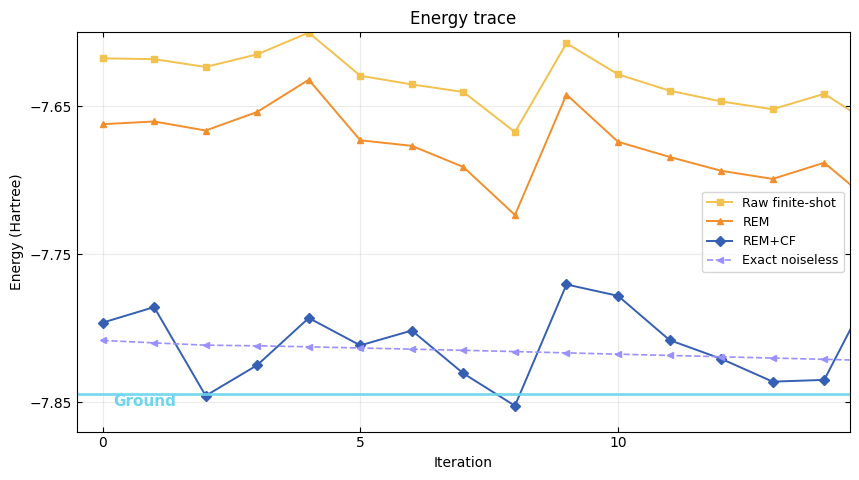

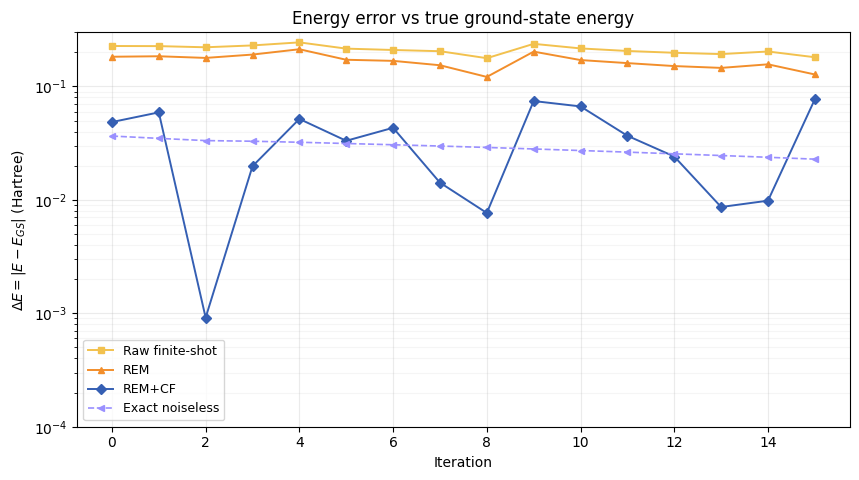

In [24]:
# --- VQE plots (panel-b style): energy + log-scale error vs true GS ---
import matplotlib.pyplot as plt
import numpy as np

if "vqe_results" not in globals():
    raise RuntimeError("Run the VQE loop cell first (defines vqe_results).")

ec = vqe_results["energy_curves"]
xs = np.asarray([float(r["iter"]) for r in ec], dtype=float)
raw = np.asarray([float(r["raw_eh"]) for r in ec], dtype=float)
rem = np.asarray([float(r["rem_eh"]) for r in ec], dtype=float)
cf = np.asarray([float(r["rem_cf_eh"]) for r in ec], dtype=float)
nls = np.asarray([float(r["noiseless_eh"]) for r in ec], dtype=float)

# True ground-state energy reference.
if "true_gs_energy" in globals():
    e_gs = float(true_gs_energy)
elif "gs_energy" in globals():
    e_gs = float(gs_energy)
else:
    hmat = pauli_sum.matrix(qubits=qubits)
    e_gs = float(np.linalg.eigvalsh(hmat)[0].real)

# Panel-b-like colors/markers
style_raw = dict(color="#f2c14e", marker="s", ms=5, lw=1.4, label="Raw finite-shot")
style_rem = dict(color="#f28e2b", marker="^", ms=5, lw=1.4, label="REM")
style_cf = dict(color="#355fb3", marker="D", ms=4.8, lw=1.4, label="REM+CF")
style_nls = dict(color="#9a90ff", marker="<", ms=5, lw=1.2, linestyle="--", label="Exact noiseless")

fig1, ax1 = plt.subplots(figsize=(8.7, 4.9))
ax1.plot(xs, raw, **style_raw)
ax1.plot(xs, rem, **style_rem)
ax1.plot(xs, cf, **style_cf)
ax1.plot(xs, nls, **style_nls)
ax1.axhline(e_gs, color="#6dd5ed", lw=2.0, alpha=0.9)
ax1.text(xs.min() + 0.2, e_gs, "Ground", color="#6dd5ed", va="top", ha="left", fontsize=11, weight="bold")
# Panel-b tick style (match reference figure)
ax1.set_xticks([0, 5, 10])
ax1.set_xlim(-0.5, 14.5)
ax1.set_yticks([-7.85, -7.75, -7.65])
ax1.set_ylim(-7.87, -7.60)
ax1.tick_params(axis="both", which="both", direction="in", top=True, right=True)
ax1.set_xlabel("Iteration")
ax1.set_ylabel("Energy (Hartree)")
ax1.set_title("Energy trace")
ax1.grid(True, alpha=0.25)
ax1.legend(loc="best", fontsize=9)
fig1.tight_layout()

# Absolute errors, shown on log-y axis to display 10^-1 ... 10^-4 style ticks.
floor = 1e-16
err_raw = np.maximum(np.abs(raw - e_gs), floor)
err_rem = np.maximum(np.abs(rem - e_gs), floor)
err_cf = np.maximum(np.abs(cf - e_gs), floor)
err_nls = np.maximum(np.abs(nls - e_gs), floor)

fig2, ax2 = plt.subplots(figsize=(8.7, 4.9))
ax2.plot(xs, err_raw, **style_raw)
ax2.plot(xs, err_rem, **style_rem)
ax2.plot(xs, err_cf, **style_cf)
ax2.plot(xs, err_nls, **style_nls)
ax2.set_yscale("log")
ax2.set_ylim(1e-4, 3e-1)
ax2.set_yticks([1e-1, 1e-2, 1e-3, 1e-4])
ax2.set_xlabel("Iteration")
ax2.set_ylabel(r"$\Delta E = |E - E_{GS}|$ (Hartree)")
ax2.set_title("Energy error vs true ground-state energy")
ax2.grid(True, which="major", alpha=0.25)
ax2.grid(True, which="minor", alpha=0.12)
ax2.legend(loc="best", fontsize=9)
fig2.tight_layout()

print(f"Using true GS reference energy: {e_gs:.12f} Eh")
plt.show()
